# 🏡 California House Price Prediction

In this project, we aim to predict the **median house value** (`median_house_value`) in California using various housing features, such as longitude, latitude, median neighborhood income, proximity to the ocean, and other related attributes.

The model used in this project is a **Random Forest Regressor**, with hyperparameter optimization performed using **GridSearchCV** to improve prediction performance.

# Import Libraries

In [7]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Data Loading

In [8]:
df = pd.read_csv('housing.csv')

print("Dataset Info:")
print(df.info())
display(df.head())

y = df['median_house_value']
X = df.drop('median_house_value', axis=1)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# EDA


In [9]:
df.shape

(20640, 10)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [11]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [12]:
# fill massing values in total_bedrooms with mean
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean())

In [13]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [14]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,419.266592,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,438.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


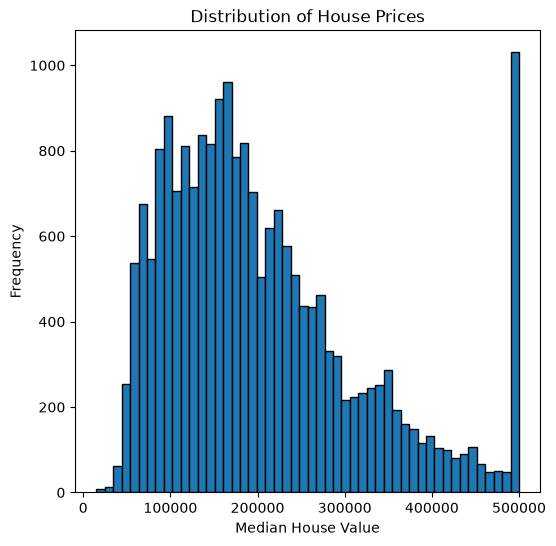

In [15]:
plt.figure(figsize = (6,6))
plt.hist(df['median_house_value'],bins=50,edgecolor='black');
plt.title('Distribution of House Prices')
plt.xlabel('Median House Value')
plt.ylabel('Frequency');

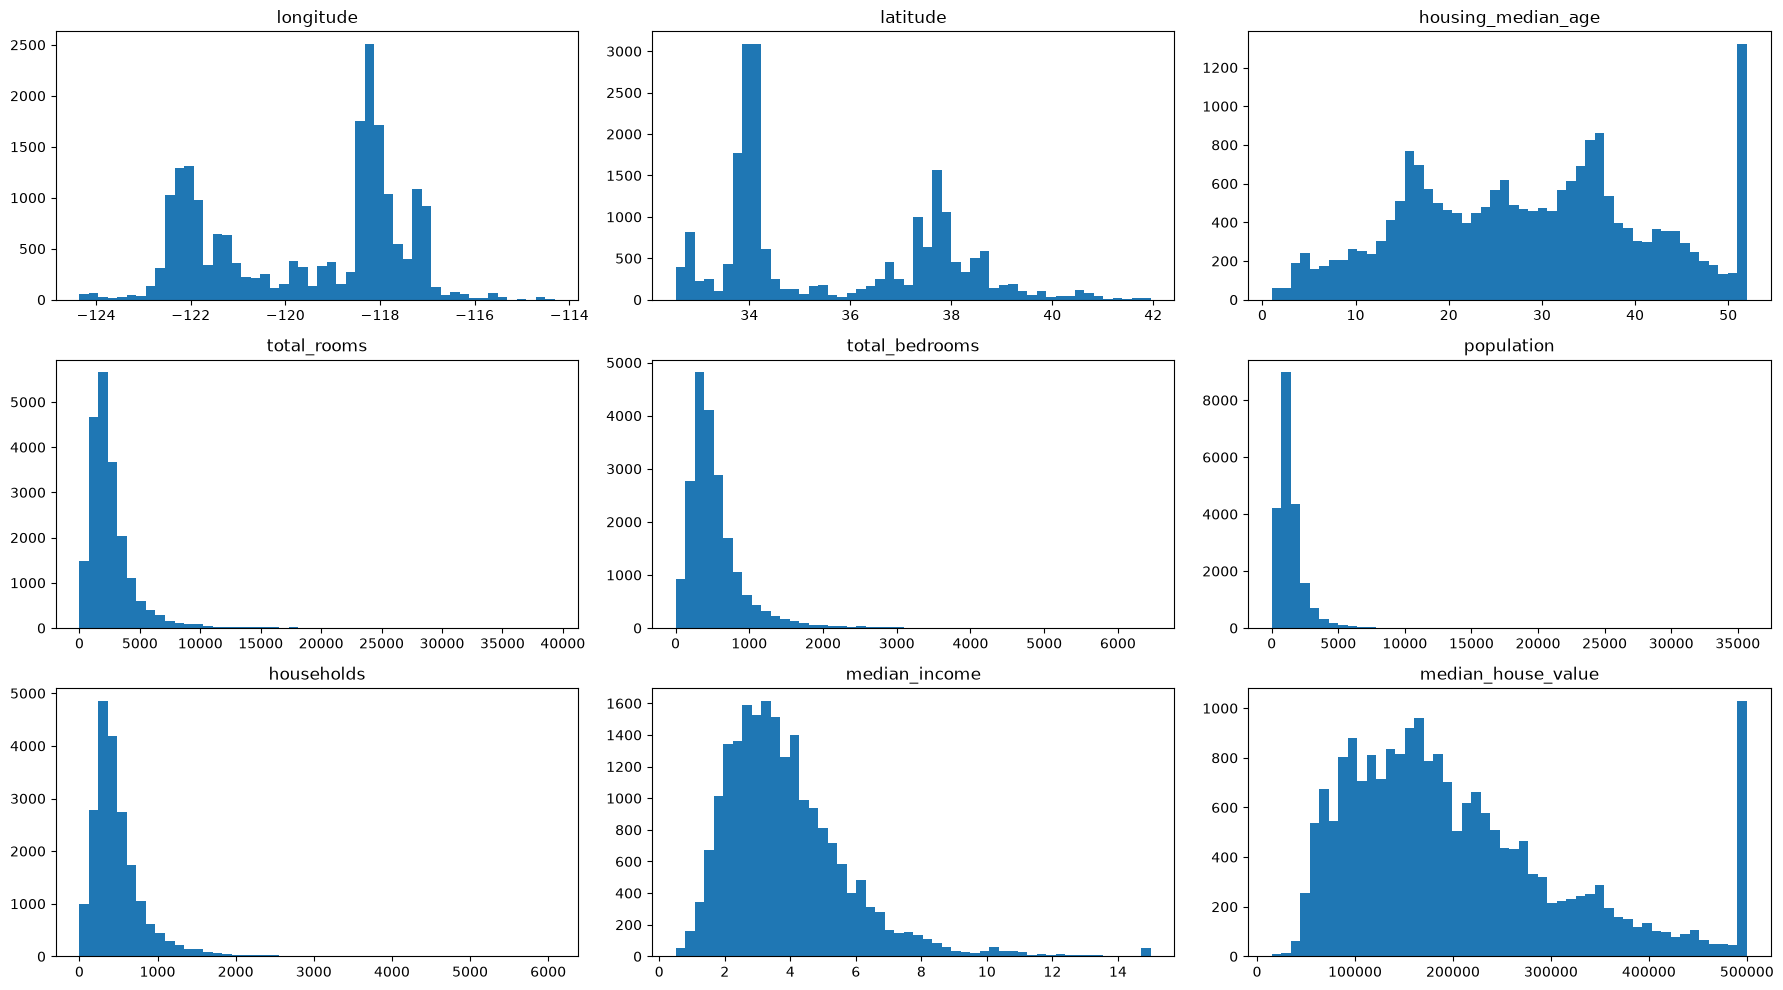

In [16]:
df.hist(bins=50, grid=False, figsize=(18,10))

plt.tight_layout()

# Irregular data (Outliers)

<Axes: >

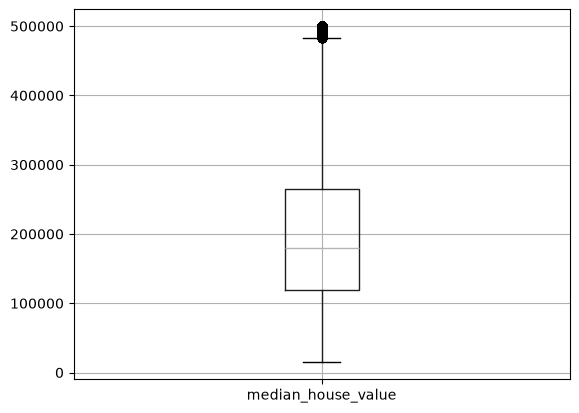

In [17]:
# box plot.
df.boxplot(column=['median_house_value'])

In [18]:
df['median_house_value'].describe()


count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64

# The 500001 value is an outlier

In [19]:
df[df['median_house_value'] == 500001]['median_house_value'].count()

np.int64(965)

In [20]:
print((965/ 20640)*100)

4.675387596899225


# Unnecessary Data — Repetitive Data, Duplicates and more


In [21]:
# remove households column
df =  df.drop(columns=['households'])

<Axes: xlabel='latitude', ylabel='longitude'>

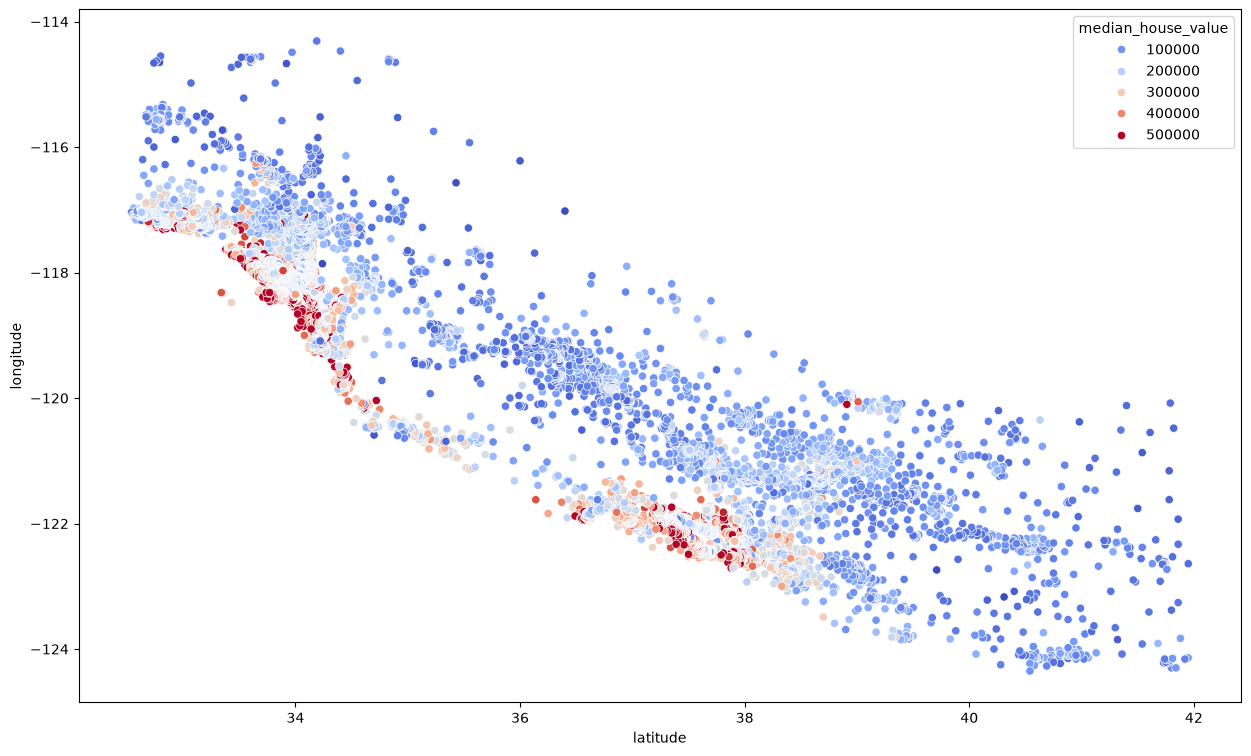

In [22]:
plt.figure(figsize=(15,9))
sns.scatterplot(x='latitude', y='longitude',data=df,hue = 'median_house_value',palette = 'coolwarm')

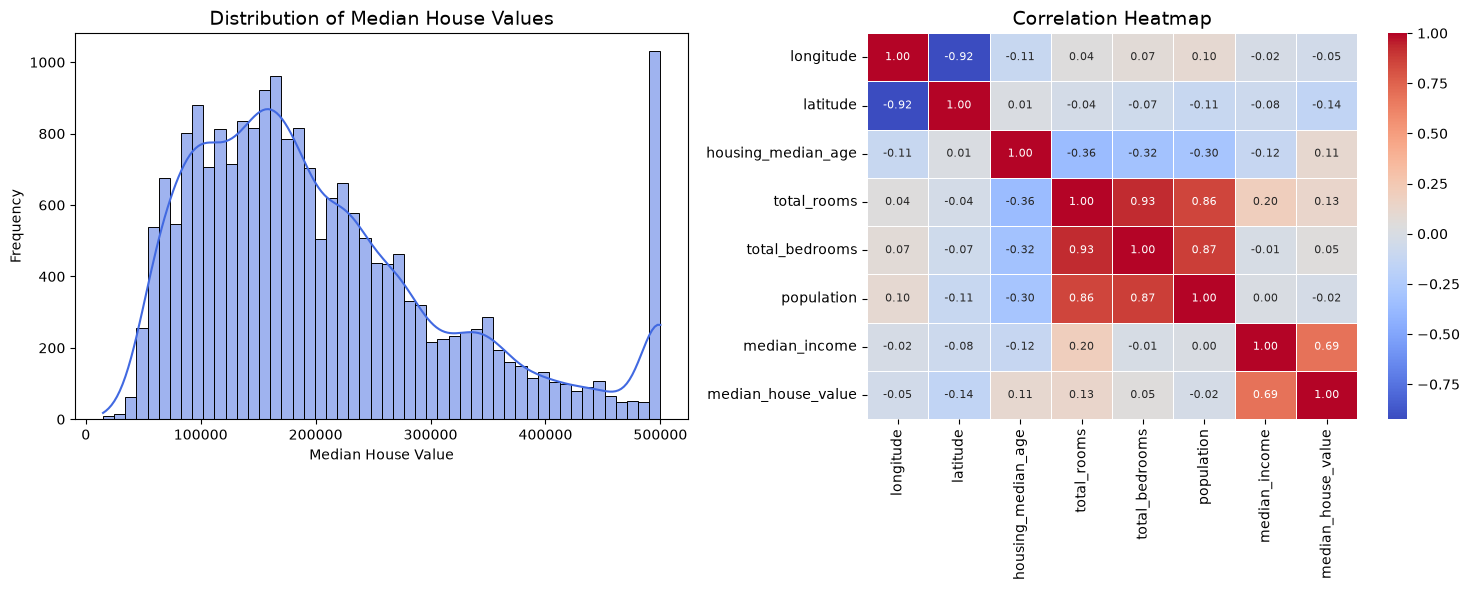

In [23]:
# Create a figure with two subplots
plt.figure(figsize=(15, 6))

# -------------------------------
# Plot 1: Distribution of house prices
# -------------------------------
plt.subplot(1, 2, 1)

# Display the distribution of the target variable
sns.histplot(y, kde=True, bins=50, color='royalblue')

plt.title('Distribution of Median House Values', fontsize=14)
plt.xlabel('Median House Value')
plt.ylabel('Frequency')

# -------------------------------
# Plot 2: Correlation Heatmap
# -------------------------------
plt.subplot(1, 2, 2)

# Select only numerical columns for correlation analysis
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Compute and visualize the correlation matrix
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    annot_kws={"size": 8}
)

plt.title('Correlation Heatmap', fontsize=14)

# Adjust subplot spacing and display the figure
plt.tight_layout()
plt.show()

# Data Preprocessing

In [24]:
# 1. Separate numerical and categorical columns
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = ['ocean_proximity']

# 2. Handle missing values using median imputation
num_imputer = SimpleImputer(strategy='median')
X[numeric_cols] = num_imputer.fit_transform(X[numeric_cols])

# 3. Apply One-Hot Encoding to categorical features
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Save feature names for future predictions
final_columns = list(X.columns)

# 4. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Preprocessing Completed! Train features shape: {X_train_scaled.shape}")

✅ Preprocessing Completed! Train features shape: (16512, 12)


# Model Training & Tuning

In [25]:
rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Define the hyperparameter grid for tuning
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5]
}

# Configure Grid Search with Cross-Validation
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

# Train the model and search for the best hyperparameters
print("⏳ Training model... This might take a few minutes.")
grid_search.fit(X_train_scaled, y_train)

# Retrieve the best-performing model
best_model = grid_search.best_estimator_

# Display the optimal hyperparameters
print(f"\n✅ Best Parameters Found: {grid_search.best_params_}")

⏳ Training model... This might take a few minutes.
Fitting 3 folds for each of 8 candidates, totalling 24 fits


[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   5.5s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   5.6s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   5.9s
[CV] END max_depth=10, min_samples_split=2, n_estimators=200; total time=  11.5s
[CV] END max_depth=10, min_samples_split=2, n_estimators=200; total time=  10.7s
[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time=   5.5s
[CV] END max_depth=10, min_samples_split=2, n_estimators=200; total time=  11.4s
[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time=   5.5s
[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time=   5.8s
[CV] END max_depth=10, min_samples_split=5, n_estimators=200; total time=  11.1s
[CV] END max_depth=10, min_samples_split=5, n_estimators=200; total time=  10.3s
[CV] END max_depth=20, min_samples_split=2, n_estimators=100; total time=   8.5s
[CV] END max_depth=10, min_s

# Evaluation

📊 Mean Absolute Error (MAE): $31,589.93
📊 Root Mean Squared Error (RMSE): $48,899.12
📊 R-squared (R2 Score): 0.8175


/tmp/ipykernel_10128/494722715.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances, y=top_features, palette='viridis')


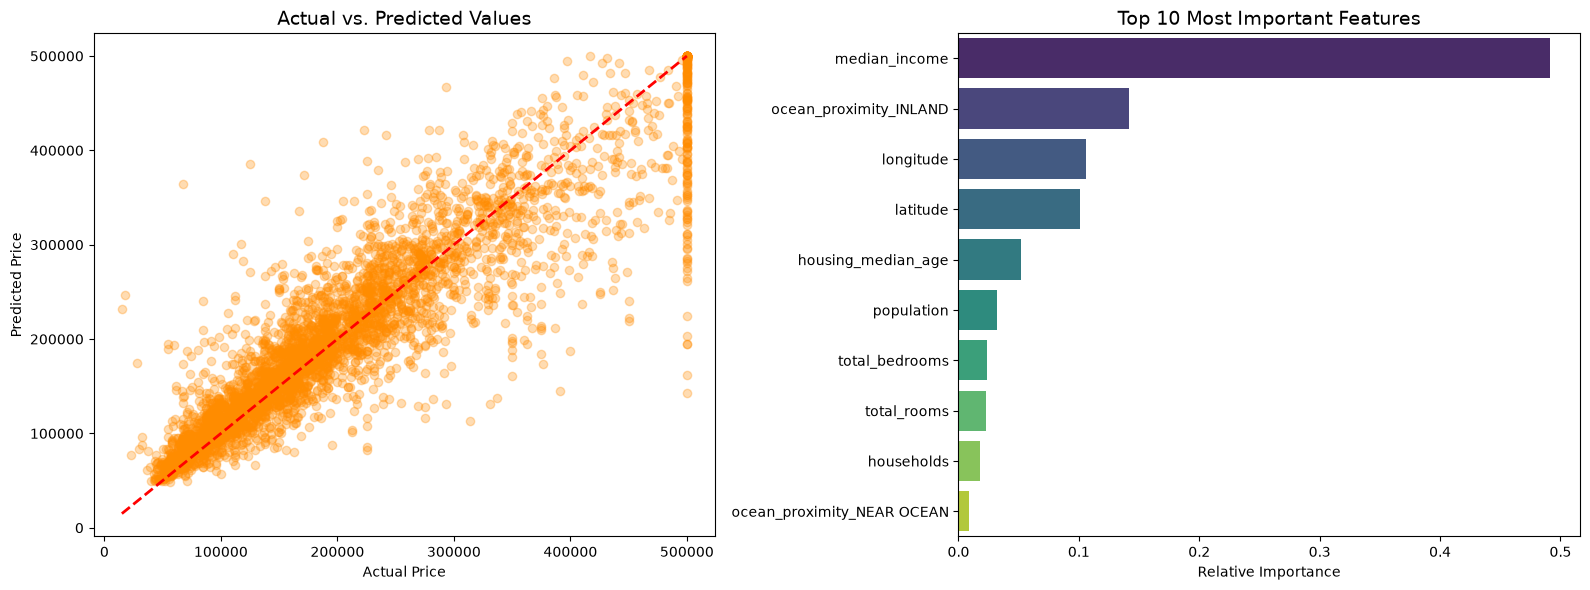

In [26]:
# Make predictions on the test dataset
y_pred = best_model.predict(X_test_scaled)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"📊 Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"📊 Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"📊 R-squared (R2 Score): {r2:.4f}")

# Visualize model performance
plt.figure(figsize=(16, 6))

# Plot actual values vs predicted values
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.3, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Values', fontsize=14)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

# Plot feature importance
plt.subplot(1, 2, 2)

# Get feature importance scores from the trained model
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Select the top 10 most important features
top_features = [final_columns[i] for i in indices[:10]]
top_importances = importances[indices[:10]]

sns.barplot(x=top_importances, y=top_features, palette='viridis')
plt.title('Top 10 Most Important Features', fontsize=14)
plt.xlabel('Relative Importance')

plt.tight_layout()
plt.show()

# Export

In [27]:
joblib.dump(best_model, 'house_price_rf_model.pkl')
joblib.dump(scaler, 'standard_scaler.pkl')
joblib.dump(final_columns, 'model_columns.pkl')

print("🚀 Model, Scaler, and Column structure exported successfully!")

🚀 Model, Scaler, and Column structure exported successfully!
